In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('spam.csv', encoding='utf-8', encoding_errors='ignore')


In [3]:
df.sample(5) #gives sample any random 5 values

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5102,spam,This msg is for your mobile content order It h...,NaN,NaN,NaN
344,ham,My sister cleared two round in birla soft yest...,NaN,NaN,NaN
5447,ham,So that takes away some money worries,NaN,NaN,NaN
781,ham,"Hmmm ... I thought we said 2 hours slave, not ...",NaN,NaN,NaN
738,ham,Wish i were with you now!,NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

In [5]:
#1.Data Cleaning
#2.EDA
#3.Text Processing
#4.Model Building
#5.Evaluation
#6.Improvemnt
#7.Website
#8.Deploy

## Data Cleaning

In [6]:
#drop last three columns 
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [7]:
df.sample(4)

,v1,v2
838,spam,We tried to contact you re our offer of New Vi...
1240,ham,Oh yes I can speak txt 2 u no! Hmm. Did u get ...
1785,ham,I dun believe u. I thk u told him.
5190,spam,Our records indicate u maybe entitled to 5000 ...


In [8]:
#renaming the cols
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
1766,spam,SMS AUCTION You have won a Nokia 7250i. This i...
4674,spam,"Hi babe its Chloe, how r u? I was smashed on s..."
1185,ham,Annoying isn't it.
1994,ham,Have you been practising your curtsey?
853,ham,\AH POOR BABY!HOPE URFEELING BETTERSN LUV! PRO...


In [9]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [10]:
df['target']=encoder.fit_transform(df['target'])

In [11]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
#missing values 
df.isnull().sum()

target    0
text      0
dtype: int64

In [13]:
#check for duplicate values
df.duplicated().sum()

np.int64(404)

In [14]:
df=df.drop_duplicates(keep='first')

In [15]:
df.shape

(5168, 2)

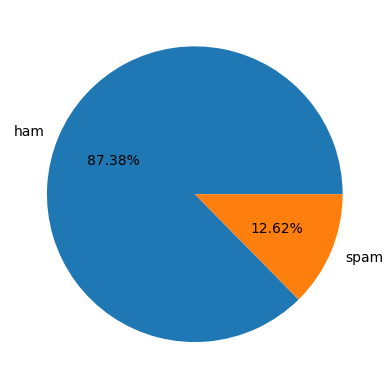

In [16]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct='%0.2f%%')
plt.show()

In [17]:
#Data is imbalanced 


In [18]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize

In [19]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\muska\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [20]:
df['num_characters']=df['text'].apply(len) # it will calculate each cahracter

In [21]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [22]:
#num of words
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\muska\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [23]:
df['num_words'] = df['text'].apply(lambda x: len(word_tokenize(x)))

In [24]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [25]:
 df['num_sentences']=df['text'].apply(lambda x: len(sent_tokenize(x)))

In [26]:
df.head(5)

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [27]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5168.000000,5168.000000,5168.000000
mean,78.759481,18.441176,1.966331
std,58.104099,13.327587,1.449367
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,116.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [28]:
#summary statistics of three columns of ham messages
df[df['target']==0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.344110,17.108946,1.819973
std,56.328803,13.494730,1.383228
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [29]:
#spam messages
df[df['target']==1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,652.000000,652.000000,652.000000
mean,137.047546,27.668712,2.980061
std,29.937352,7.015283,1.491780
min,13.000000,2.000000,1.000000
25%,130.000000,25.000000,2.000000
50%,148.000000,29.000000,3.000000
75%,156.000000,32.000000,4.000000
max,222.000000,46.000000,9.000000


In [30]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

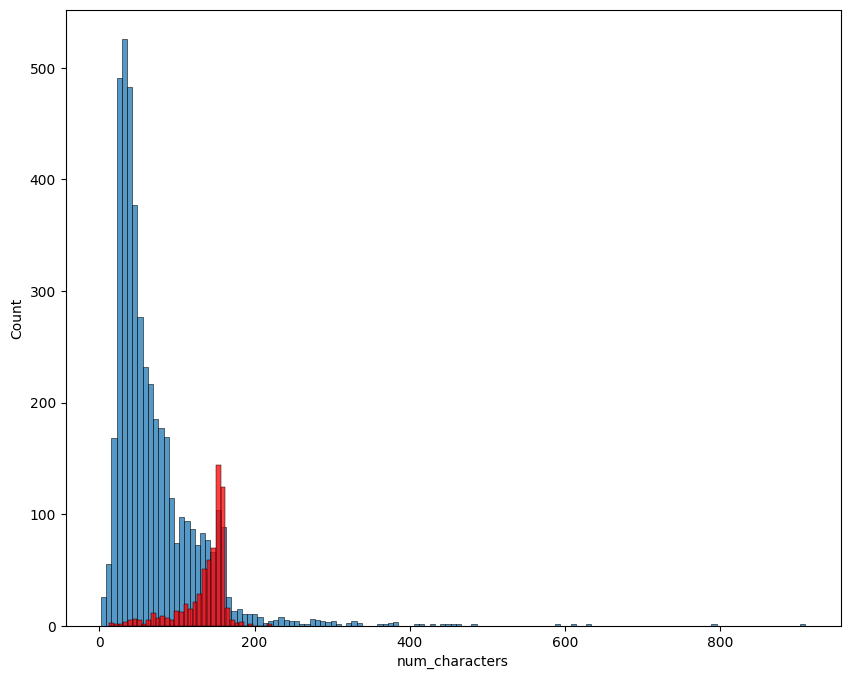

In [31]:
plt.figure(figsize=(10,8))
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

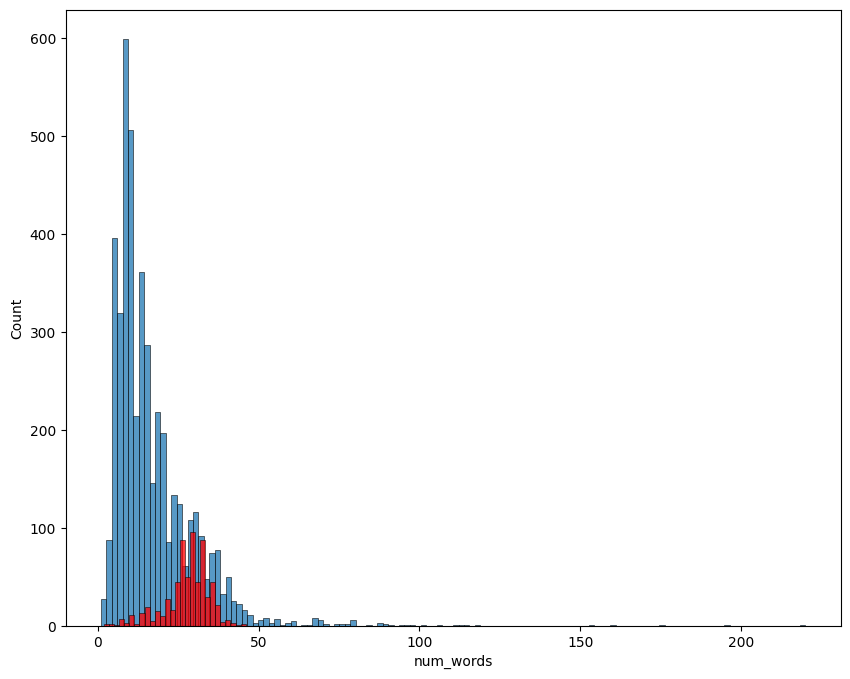

In [32]:
plt.figure(figsize=(10,8))
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'],color='red')

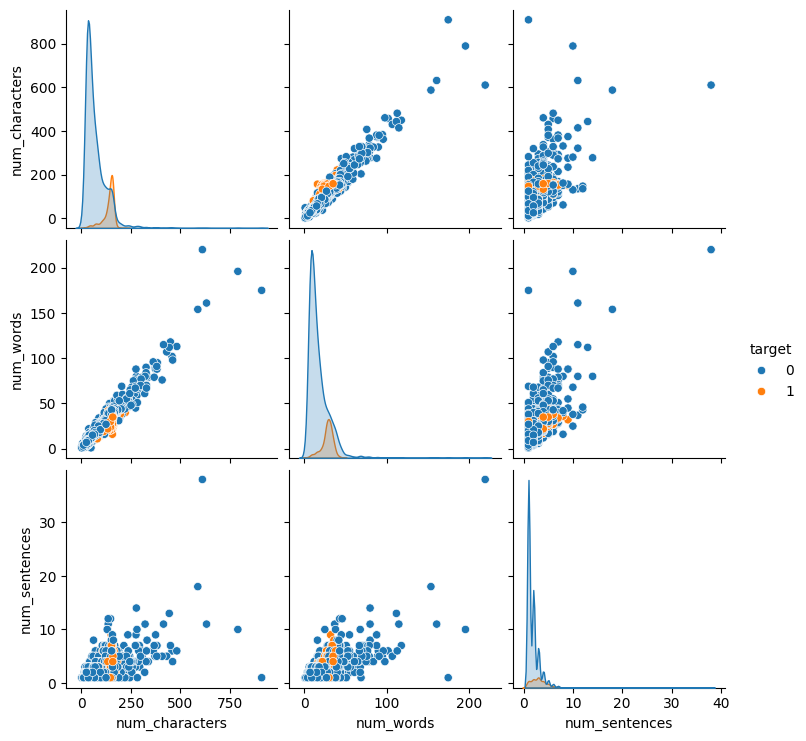

In [33]:
sns.pairplot(df,hue='target')

<Axes: >

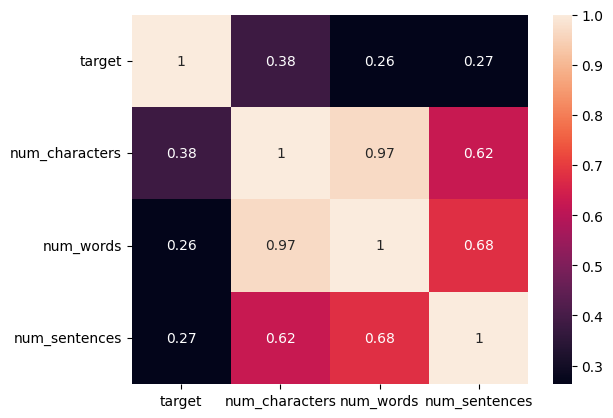

In [34]:
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True)


## Data Preproccesing

**lower case**

**Tokenization**

**removing special characters**

**removing stop words and punctuation**

**stemming**

In [35]:
def transform_text(text):
    text=text.lower()
    text=nltk.word_tokenize(text)

    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)

    text=y[:] # if i dont write copy then both the varaibles will refer to one object
    y.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text=y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))
    

    return " ".join(y)
    

In [42]:
nltk.download('stopwords')
from nltk.corpus import stopwords
stopwords.words('english')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\muska\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [55]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [44]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()
ps.stem('loving')

'love'

In [56]:
df['transformed_text']=df['text'].apply(transform_text)

In [57]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [58]:
#A word cloud (also called a tag cloud) is a visual summary of text data where each word’s size (and sometimes its color) reflects how frequently it appears in the document or dataset 

In [59]:
from wordcloud import WordCloud
from collections import Counter
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [60]:
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))

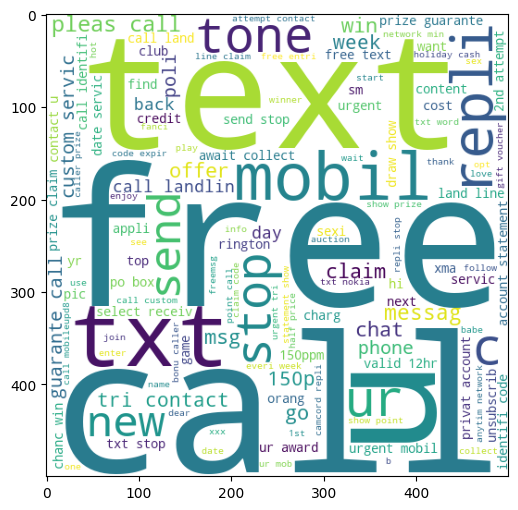

In [61]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [62]:
ham_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))

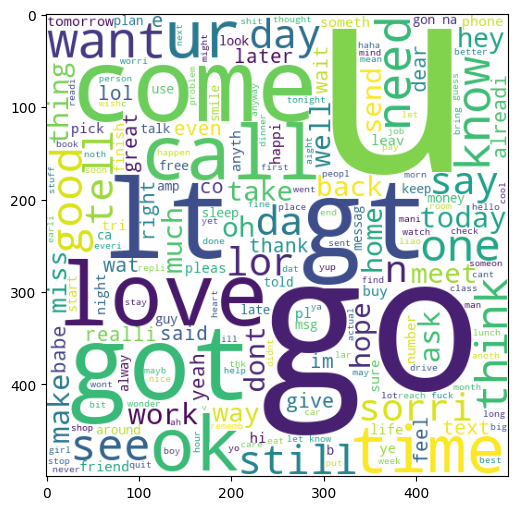

In [63]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [64]:
ham_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" ")) #" ".join(...) but vectorized inpandas

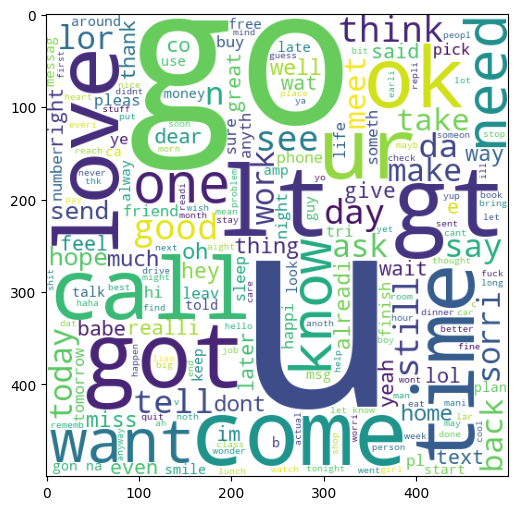

In [65]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [66]:
# df['target'] == 0
# Creates a boolean mask selecting only the rows that are ham (i.e., target equals 0).

# df[mask]['transformed_text']
# Filters the DataFrame to those ham rows and selects the column transformed_text, which typically contains preprocessed text (e.g., lowercased, tokenized, stemmed).

# .str.cat(sep=" ")
# Concatenates all those rows of transformed_text into one long string, with a space (" ") separating each entry.

# Equivalent to " ".join(...) but vectorized for pandas.

# This forms the text corpus that the word cloud generator will use. 
    
# wc.generate(...)
# Takes that single big string and computes word frequencies, then builds a word cloud image where word size reflects how often each word appears .

In [67]:
spam_corpus=[]
for msg in df[df['target']==1]['transformed_text'].tolist():
    # print(msg)
    for word in msg.split():
        # print(word)
        spam_corpus.append(word)

In [68]:
len(spam_corpus)

10106

<Axes: xlabel='count', ylabel='word'>

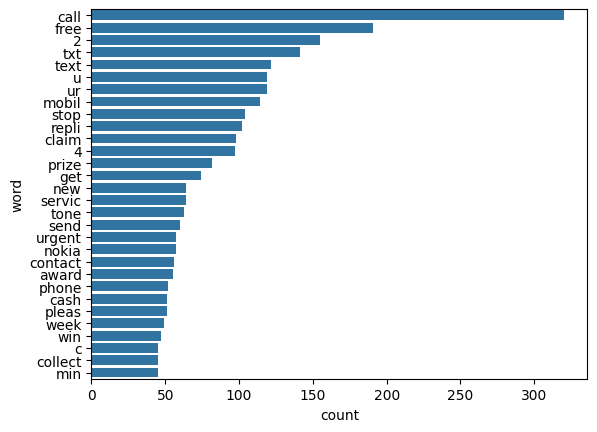

In [69]:

# Count top 30 spam words
common = Counter(spam_corpus).most_common(30)
words, counts = zip(*common)
df_common = pd.DataFrame({'word': words, 'count': counts})

# Correct barplot usage
sns.barplot(x='count', y='word', data=df_common)


In [70]:
ham_corpus=[]
for msg in df[df['target']==0]['transformed_text'].tolist():
    # print(msg)
    for word in msg.split():
        # print(word)
        ham_corpus.append(word)

<Axes: xlabel='count', ylabel='word'>

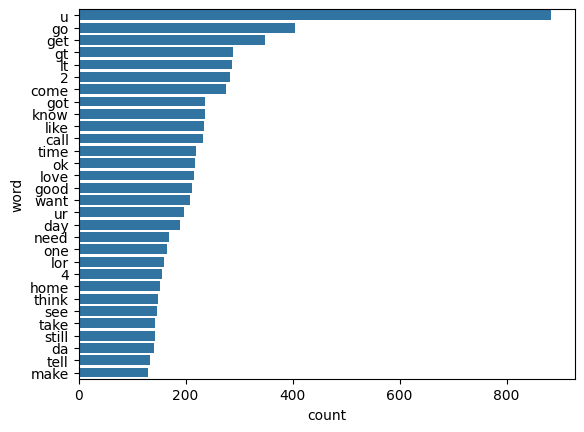

In [71]:
common = Counter(ham_corpus).most_common(30)
words, counts = zip(*common)
df_common = pd.DataFrame({'word': words, 'count': counts})

# Correct barplot usage
sns.barplot(x='count', y='word', data=df_common)

## Model Building

In [84]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv=CountVectorizer()
tfidf=TfidfVectorizer(max_features=3000) #after max features the  accuracy got better and precision was 1.00

In [85]:
X=tfidf.fit_transform(df['transformed_text']).toarray()


In [86]:
X.shape

(5168, 3000)

In [87]:
Y=df['target'].values

In [88]:
Y

array([0, 0, 1, ..., 0, 0, 0], shape=(5168,))

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [90]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [91]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB

In [92]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [93]:
gnb.fit(X_train,Y_train)
Y_pred1=gnb.predict(X_test)
print(accuracy_score(Y_test,Y_pred1))
print(confusion_matrix(Y_test,Y_pred1))
print(precision_score(Y_test,Y_pred1))

0.874274661508704
[[789 104]
 [ 26 115]]
0.5251141552511416


In [94]:
mnb.fit(X_train,Y_train)
Y_pred2=mnb.predict(X_test)
print(accuracy_score(Y_test,Y_pred2))
print(confusion_matrix(Y_test,Y_pred2))
print(precision_score(Y_test,Y_pred2))

0.9709864603481625
[[893   0]
 [ 30 111]]
1.0


In [95]:
bnb.fit(X_train,Y_train)
Y_pred3=bnb.predict(X_test)
print(accuracy_score(Y_test,Y_pred3))
print(confusion_matrix(Y_test,Y_pred3))
print(precision_score(Y_test,Y_pred3))

0.9787234042553191
[[892   1]
 [ 21 120]]
0.9917355371900827


In [96]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))